# Project 1: Simulation and estimation in a Markov model of breast cancer

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import expm

np.random.seed(42)

# Transition probability matrix (discrete-time)
P = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0  ]
])

# Quick sanity check, rows must sum to 1
print("Row sums:", P.sum(axis=1))

Row sums: [1. 1. 1. 1. 1.]


## Part 1:  A discrete-time model 

In [9]:
#Simulate 1000 women until death (state 5, index 4)
def simulate_women(P, n=1000, start_state=0):
    """
    Simulate n women through the Markov chain until death (state index 4).
    Returns:
        lifetimes: array of months until death
        trajectories: list of state sequences
    """
    states = list(range(P.shape[0]))
    lifetimes = []
    trajectories = []

    for _ in range(n):
        state = start_state
        path = [state]
        t = 0
        while state != 4:  # state 4 = death
            state = np.random.choice(states, p=P[state])
            t += 1
            path.append(state)
        lifetimes.append(t)
        trajectories.append(path)

    return np.array(lifetimes), trajectories

lifetimes, trajectories = simulate_women(P, n=1000)

print(f"Mean lifetime:   {lifetimes.mean():.1f} months  ({lifetimes.mean()/12:.1f} years)")
print(f"Median lifetime: {np.median(lifetimes):.1f} months")
print(f"Std deviation:   {lifetimes.std():.1f} months")
print(f"Min / Max:       {lifetimes.min()} / {lifetimes.max()} months")

Mean lifetime:   265.0 months  (22.1 years)
Median lifetime: 224.0 months
Std deviation:   184.4 months
Min / Max:       1 / 1151 months


### Task 1: Lifetime distribution histogram

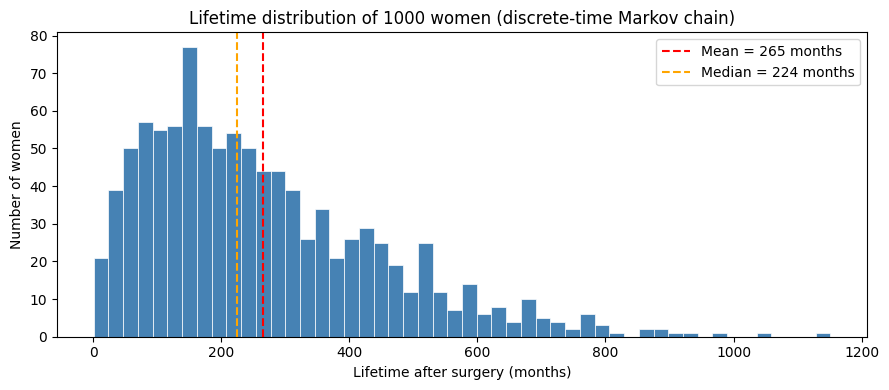

Proportion with local recurrence: 0.589 (589/1000 women)


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(lifetimes, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(lifetimes.mean(),   color='red',    linestyle='--', label=f'Mean = {lifetimes.mean():.0f} months')
ax.axvline(np.median(lifetimes), color='orange', linestyle='--', label=f'Median = {np.median(lifetimes):.0f} months')

ax.set_xlabel('Lifetime after surgery (months)')
ax.set_ylabel('Number of women')
ax.set_title('Lifetime distribution of 1000 women (discrete-time Markov chain)')
ax.legend()
plt.tight_layout()
plt.show()

# Also answer: proportion who ever entered local recurrence (state 1, index 1)
local_recurrence = sum(1 for path in trajectories if 1 in path[1:])
print(f"Proportion with local recurrence: {local_recurrence/1000:.3f} ({local_recurrence}/1000 women)")

- The distribution is right-skewed. Long tail of women who survive many years.
- 58.9% of women eventually experienced local recurrence

### Task 2: State distribution at t=120 months

In [11]:
t = 120

# --- Theoretical distribution: p_t = p0 @ P^t ---
p0 = np.array([1, 0, 0, 0, 0])  # all women start in state 1
Pt = np.linalg.matrix_power(P, t)
p_theoretical = p0 @ Pt
print("Theoretical state distribution at t=120:")
for i, p in enumerate(p_theoretical):
    print(f"  State {i+1}: {p:.6f}")

# --- Empirical: count where each woman is at month 120 ---
state_at_120 = np.zeros(5, dtype=int)
for path in trajectories:
    if len(path) > t:
        state_at_120[path[t]] += 1
    else:
        state_at_120[4] += 1  # already dead

print(f"\nEmpirical state counts at t=120: {state_at_120}")
print(f"Empirical proportions:          {state_at_120/1000}")

# --- Chi-square test ---
expected = p_theoretical * 1000
# Only include states with expected count > 0
mask = expected > 0
chi2, p_value = stats.chisquare(f_obs=state_at_120[mask], f_exp=expected[mask])
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value:              {p_value:.4f}")
print(f"Conclusion: {'Consistent with theory (fail to reject H0)' if p_value > 0.05 else 'Inconsistent with theory (reject H0)'}")

Theoretical state distribution at t=120:
  State 1: 0.359026
  State 2: 0.158956
  State 3: 0.166087
  State 4: 0.067741
  State 5: 0.248189

Empirical state counts at t=120: [364 165 167  69 235]
Empirical proportions:          [0.364 0.165 0.167 0.069 0.235]

Chi-square statistic: 1.0280
P-value:              0.9055
Conclusion: Consistent with theory (fail to reject H0)


The empirical proportions are extremely close to the theoretical ones, and the p-value of 0.91 is very high so we have no reason to reject H0. 

The simulation is behaving as the math predicts.

### Task 3: Compare simulated lifetimes to phase-type distribution

Theoretical mean lifetime: 262.37 months (21.86 years)
Simulated  mean lifetime:  265.04 months (22.09 years)

KS statistic: 0.0236
P-value:      0.6257
Conclusion: Consistent with phase-type distribution (fail to reject H0)


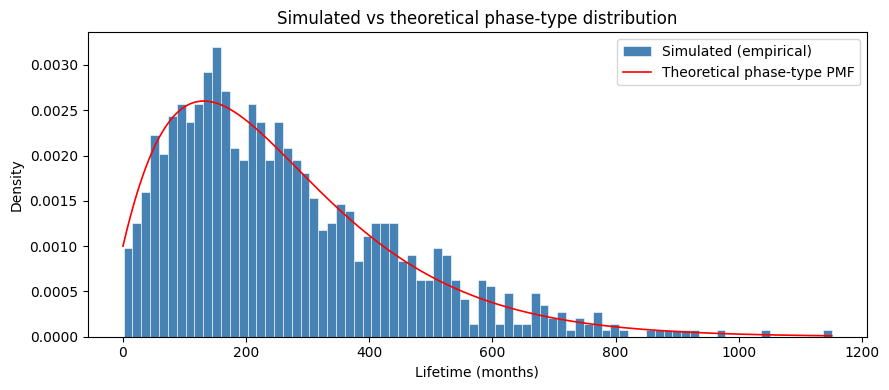

In [12]:
# Ps = sub-matrix of P (remove last row and column)
Ps = P[:4, :4]

# ps = probability of dying from each transient state (last column, first 4 rows)
ps = P[:4, 4]

# pi = initial distribution over transient states
pi = np.array([1, 0, 0, 0])

# Theoretical PMF: P(T=t) = pi @ Ps^t @ ps
max_t = int(lifetimes.max()) + 1
pmf_theoretical = np.zeros(max_t)
for t in range(max_t):
    Ps_t = np.linalg.matrix_power(Ps, t)
    pmf_theoretical[t] = pi @ Ps_t @ ps

# Theoretical mean: E(T) = pi @ (I - Ps)^{-1} @ 1
I = np.eye(4)
mean_theoretical = pi @ np.linalg.inv(I - Ps) @ np.ones(4)
print(f"Theoretical mean lifetime: {mean_theoretical:.2f} months ({mean_theoretical/12:.2f} years)")
print(f"Simulated  mean lifetime:  {lifetimes.mean():.2f} months ({lifetimes.mean()/12:.2f} years)")

# KS test: compare simulated lifetimes to theoretical CDF
cdf_theoretical = np.cumsum(pmf_theoretical)
cdf_at_simulated = cdf_theoretical[lifetimes]  # CDF value at each simulated lifetime

ks_stat, p_value = stats.kstest(lifetimes, lambda t: cdf_theoretical[np.minimum(t.astype(int), max_t-1)])
print(f"\nKS statistic: {ks_stat:.4f}")
print(f"P-value:      {p_value:.4f}")
print(f"Conclusion: {'Consistent with phase-type distribution (fail to reject H0)' if p_value > 0.05 else 'Inconsistent (reject H0)'}")

# Plot: empirical vs theoretical PMF
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lifetimes, bins=80, density=True, color='steelblue', edgecolor='white',
        linewidth=0.4, label='Simulated (empirical)')
ax.plot(range(max_t), pmf_theoretical, color='red', linewidth=1.2,
        label='Theoretical phase-type PMF')
ax.set_xlabel('Lifetime (months)')
ax.set_ylabel('Density')
ax.set_title('Simulated vs theoretical phase-type distribution')
ax.legend()
plt.tight_layout()
plt.show()

### Task 4: Rejection sampling for conditional expected lifetime

In [13]:

def simulate_one_woman(P):
    """Simulate a single woman, return (lifetime, path)."""
    states = list(range(5))
    state = 0
    path = [state]
    t = 0
    while state != 4:
        state = np.random.choice(states, p=P[state])
        t += 1
        path.append(state)
    return t, path

def condition_met(path):
    """
    Returns True if:
    - Woman survives first 12 months (death not in path[:13])
    - Cancer reappeared locally (state 1) OR distantly (state 2 or 3)
      within first 12 months
    """
    first_12 = path[:13]  # indices 0..12 = months 0..12
    # Must survive 12 months
    if 4 in first_12:
        return False
    # Cancer must have reappeared: state 1 (local), 2 (distant), or 3 (both)
    recurrence_states = {1, 2, 3}
    if not any(s in recurrence_states for s in first_12):
        return False
    return True

# Rejection sampling until 1000 valid simulations
accepted_lifetimes = []
total_simulated = 0

while len(accepted_lifetimes) < 1000:
    t, path = simulate_one_woman(P)
    total_simulated += 1
    if condition_met(path):
        accepted_lifetimes.append(t)

accepted_lifetimes = np.array(accepted_lifetimes)

print(f"Total simulated:       {total_simulated}")
print(f"Accepted:              {len(accepted_lifetimes)}")
print(f"Acceptance rate:       {1000/total_simulated:.4f}")
print(f"\nEstimated E[T | condition]: {accepted_lifetimes.mean():.2f} months "
      f"({accepted_lifetimes.mean()/12:.2f} years)")

# 95% confidence interval
se = accepted_lifetimes.std() / np.sqrt(1000)
ci_low  = accepted_lifetimes.mean() - 1.96 * se
ci_high = accepted_lifetimes.mean() + 1.96 * se
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}] months")

Total simulated:       12797
Accepted:              1000
Acceptance rate:       0.0781

Estimated E[T | condition]: 178.03 months (14.84 years)
95% CI: [168.62, 187.44] months


### Task 5: Control variates variance reduction

In [14]:
# Theoretical mean lifetime (known from Task 3)
mu_known = 262.37  # E[T] from phase-type formula

n_women   = 200   # women per batch
n_batches = 100   # repetitions
threshold = 350   # months

crude_estimates = []
cv_estimates    = []

for _ in range(n_batches):
    batch_lifetimes = []
    for _ in range(n_women):
        t, _ = simulate_one_woman(P)
        batch_lifetimes.append(t)
    batch_lifetimes = np.array(batch_lifetimes)

    # Crude Monte Carlo estimate: fraction dying within 350 months
    Y = (batch_lifetimes <= threshold).mean()
    crude_estimates.append(Y)

    # Control variate: sample mean lifetime (correlated with Y)
    Z = batch_lifetimes.mean()
    cv_estimates.append((Y, Z))

crude_estimates = np.array(crude_estimates)
Y_vals = np.array([x[0] for x in cv_estimates])
Z_vals = np.array([x[1] for x in cv_estimates])

# Optimal c: c* = -Cov(Y, Z) / Var(Z)
cov_YZ = np.cov(Y_vals, Z_vals)[0, 1]
var_Z  = np.var(Z_vals, ddof=1)
c_star = -cov_YZ / var_Z
print(f"Optimal c*: {c_star:.6f}")

# Control variate estimator: Y_cv = Y + c*(Z - mu)
cv_corrected = Y_vals + c_star * (Z_vals - mu_known)

# Compare variances
var_crude = np.var(crude_estimates, ddof=1)
var_cv    = np.var(cv_corrected,    ddof=1)
reduction = var_crude / var_cv

print(f"\nCrude MC estimate (mean):  {crude_estimates.mean():.4f}")
print(f"CV estimate (mean):        {cv_corrected.mean():.4f}")
print(f"\nVariance (crude MC): {var_crude:.6f}")
print(f"Variance (CV):       {var_cv:.6f}")
print(f"Variance reduction factor: {reduction:.2f}x")

Optimal c*: 0.001954

Crude MC estimate (mean):  0.7362
CV estimate (mean):        0.7364

Variance (crude MC): 0.001043
Variance (CV):       0.000276
Variance reduction factor: 3.77x


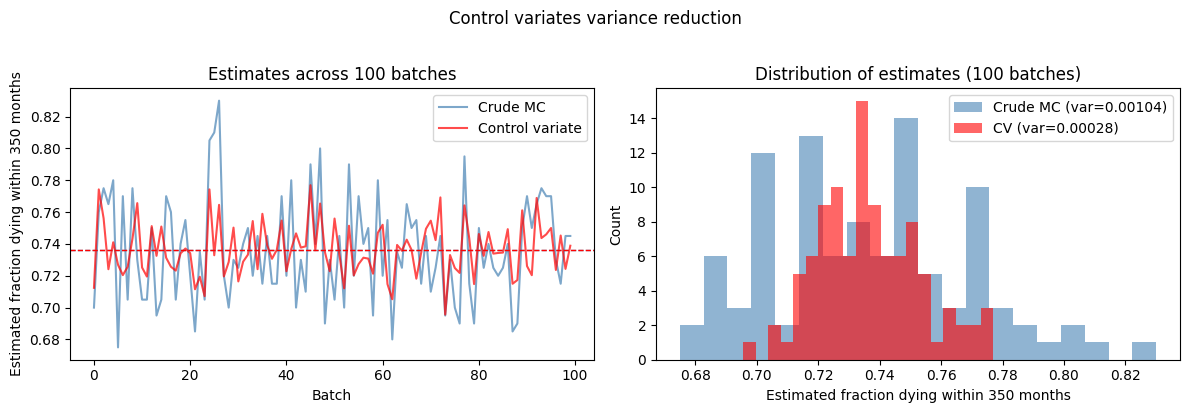

In [16]:
#Plot crude MC vs control variate estimates
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: estimates across 100 batches
axes[0].plot(crude_estimates, color='steelblue', alpha=0.7, label='Crude MC')
axes[0].plot(cv_corrected, color='red', alpha=0.7, label='Control variate')
axes[0].axhline(crude_estimates.mean(), color='steelblue', linestyle='--', linewidth=1)
axes[0].axhline(cv_corrected.mean(), color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Batch')
axes[0].set_ylabel('Estimated fraction dying within 350 months')
axes[0].set_title('Estimates across 100 batches')
axes[0].legend()

# Right: distribution of estimates
axes[1].hist(crude_estimates, bins=20, alpha=0.6, color='steelblue', label=f'Crude MC (var={var_crude:.5f})')
axes[1].hist(cv_corrected,   bins=20, alpha=0.6, color='red',       label=f'CV (var={var_cv:.5f})')
axes[1].set_xlabel('Estimated fraction dying within 350 months')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of estimates (100 batches)')
axes[1].legend()

plt.suptitle('Control variates variance reduction', y=1.02)
plt.tight_layout()
plt.show()